# TabNet Multiclass Classification

This notebook implements a complete machine learning pipeline for multiclass classification of coronary artery stenosis using TabNet, a deep learning architecture specifically designed for tabular data.

## Execution Order:
1. **Imports**: Load all required libraries including pytorch-tabnet
2. **Load Dataset**: Import and prepare the raw data
3. **Dropping dependent Features**: Remove derived variables
4. **Preprocessing**: Clean data, handle missing values, and prepare features
5. **Feature Selection**: Select top k features using mutual information
6. **SMOTE Oversampling**: Balance classes using synthetic oversampling
7. **Build and Train TabNet**: Train TabNet classifier with attention-based feature selection
8. **Evaluation**: Comprehensive evaluation metrics
9. **Overfitting Check**: Compare training vs. test performance
10. **Visualization**: ROC and Precision-Recall curves for each class
11. **Feature Importance**: TabNet's interpretable feature attributions
12. **Hyperparameter Optimization** (Optional): Find optimal TabNet parameters


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **pytorch-tabnet**: TabNet deep learning architecture for tabular data
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization


In [34]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.over_sampling import SMOTE
from scipy.sparse import issparse
import matplotlib.pyplot as plt

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import torch
    print("TabNet successfully imported")
except ImportError:
    print("ERROR: pytorch-tabnet not installed. Please install with: pip install pytorch-tabnet")
    raise


TabNet successfully imported


## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Converts European number format (commas to dots)
- Automatically converts numeric columns to appropriate data types
- Separates features (X) from the target variable (y = OUTCOME_3Kat_KHK)
- The target has 3 classes: 0 (No Stenosis), 1 (Non-significant stenosis), 2 (Significant Stenosis)


In [35]:
data = pd.read_csv(
    '../data/T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

data = data.replace(",", ".", regex=True)

for col in data.columns:
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):
        data[col] = temp

data = data.apply(pd.to_numeric, errors='ignore')

X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

print(f"Dataset shape: {data.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index())


Dataset shape: (2310, 649)
Target distribution:
OUTCOME_3Kat_KHK
0     363
1     632
2    1315
Name: count, dtype: int64


## 3. Dropping dependent Features

This cell removes dependent variables that are directly derived from other features. These features contain redundant information and can cause multicollinearity issues.


In [36]:
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]


## 4. Preprocessing

This cell performs comprehensive data preprocessing:

**Feature Type Identification:**
- Identifies categorical and numerical features
- Handles manual categorical feature definitions

**Data Cleaning (Optional):**
- **Removing highly correlated features** (correlation > 0.95) is optional for TabNet
  - **Why remove them?** (Set `REMOVE_CORRELATED = True`)
    - Reduces computational cost and memory usage
    - Can improve training speed
    - Prevents potential numerical instability
    - Reduces redundant information
  
  - **Why keep them?** (Set `REMOVE_CORRELATED = False`) - **RECOMMENDED FOR TABNET**
    - TabNet's attention mechanism can learn to ignore redundant features automatically
    - More features give TabNet more information to work with
    - TabNet's sparsity regularization (`lambda_sparse`) will naturally downweight redundant features
    - Neural networks can handle multicollinearity better than linear models
    - TabNet will learn which features are truly important through its attention masks

- Maintains 3-class target: 0 (No Stenosis), 1 (Non-significant stenosis), 2 (Significant Stenosis)

**Train/Test Split:**
- Splits data into 75% training and 25% test set
- Uses stratified split to maintain class distribution

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: kNN Imputation (k=5) + MinMax Scaling
- Falls back to IterativeImputer or Median imputation if kNN fails


In [37]:
REMOVE_CORRELATED = False

manual_categorical = [
    "geschlecht", "currsmo0", "diabetes_ADA_final_0",
    "ANY_OPE", "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

for col in manual_categorical:
    if col in X.columns:
        X[col] = X[col].astype(str)

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [col for col in numerical_features if col not in categorical_features]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

if REMOVE_CORRELATED and len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"\nRemoving {len(to_remove)} highly correlated features (correlation > 0.95)")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]
            print(f"  Remaining numerical features: {len(numerical_features)}")
        else:
            print("\nNo highly correlated features found to remove")
else:
    if not REMOVE_CORRELATED:
        print(f"\nSkipping correlation-based feature removal")
        print(f"  TabNet will handle redundant features through attention mechanisms")
        print(f"  Using all {len(numerical_features)} numerical features")

print(f"\nAfter preprocessing - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_preprocessor = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

try:
    num_preprocessor = SklearnPipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", MinMaxScaler())
    ])
    print("Using KNNImputer + MinMaxScaler")
except:
    try:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", IterativeImputer(random_state=42, max_iter=10)),
            ("scaler", MinMaxScaler())
        ])
        print("Using IterativeImputer + MinMaxScaler (fallback)")
    except:
        num_preprocessor = SklearnPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ])
        print("Using Median Imputer + MinMaxScaler (fallback)")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_preprocessor, categorical_features),
        ("num", num_preprocessor, numerical_features)
    ],
    remainder="passthrough"
)

preprocessor.fit(X_train, y_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

print(f"\nTransformed shapes:")
print(f"  Training: {X_train_transformed.shape}")
print(f"  Test: {X_test_transformed.shape}")


Categorical features: 7
Numerical features: 634

Skipping correlation-based feature removal
  TabNet will handle redundant features through attention mechanisms
  Using all 634 numerical features

After preprocessing - Numerical: 634, Categorical: 7
Using KNNImputer + MinMaxScaler

Transformed shapes:
  Training: (1732, 652)
  Test: (578, 652)


## 5. Feature Selection (Optional)

**Note:** TabNet has built-in attention-based feature selection through its architecture. The `lambda_sparse` parameter controls sparsity regularization, allowing TabNet to automatically learn which features are important.

**Why manual feature selection might still be useful:**
- **Highly correlated features**: Removing redundant features (correlation > 0.95) reduces noise and can improve training speed
- **Computational efficiency**: Fewer features mean faster training, especially with large datasets
- **Comparison**: Allows comparison with other models (XGBoost, Random Forest) that use manual feature selection

**When to skip manual feature selection:**
- TabNet's attention mechanism can handle feature selection automatically
- More features give TabNet more information to learn from
- TabNet's sparsity regularization will naturally ignore irrelevant features

This cell makes feature selection optional - set `USE_FEATURE_SELECTION = False` to let TabNet handle all feature selection automatically.


In [38]:
np.random.seed(42)

USE_FEATURE_SELECTION = False
K_FEATURES = 100

if USE_FEATURE_SELECTION:
    selector = SelectKBest(mutual_info_classif, k=K_FEATURES)
    X_train_selected = selector.fit_transform(X_train_transformed, y_train)
    X_test_selected = selector.transform(X_test_transformed)
    selected_features_mask = selector.get_support()
    
    print(f"Manual Feature Selection (SelectKBest):")
    print(f"  Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")
    print(f"  TabNet will further refine feature importance through attention mechanisms")
else:
    X_train_selected = X_train_transformed
    X_test_selected = X_test_transformed
    selected_features_mask = np.ones(X_train_transformed.shape[1], dtype=bool)
    
    print(f"No Manual Feature Selection:")
    print(f"  Using all {X_train_selected.shape[1]} features (from {X_train_transformed.shape[1]} total)")
    print(f"  TabNet will handle feature selection entirely through attention mechanisms")
    print(f"  Sparsity regularization (lambda_sparse=1e-3) will control feature importance")


No Manual Feature Selection:
  Using all 652 features (from 652 total)
  TabNet will handle feature selection entirely through attention mechanisms
  Sparsity regularization (lambda_sparse=1e-3) will control feature importance


## 6. SMOTE Oversampling

This cell applies SMOTE to handle class imbalance:
- Creates synthetic samples for minority classes
- Balances the training dataset before model training
- Uses k_neighbors=3 for synthetic sample generation


In [39]:
SMOTE_K_NEIGHBORS = 3

class_counts_before = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution before SMOTE:")
for cls, count in class_counts_before.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

smote = SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS, sampling_strategy='auto')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

class_counts_after = pd.Series(y_train_balanced).value_counts().sort_index()
print(f"\nClass distribution after SMOTE:")
for cls, count in class_counts_after.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train_balanced) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\nTraining set size: {X_train_balanced.shape[0]} samples, {X_train_balanced.shape[1]} features")


Class distribution before SMOTE:
  No Stenosis (Class 0): 272 samples (15.7%)
  Non-significant stenosis (Class 1): 474 samples (27.4%)
  Significant Stenosis (Class 2): 986 samples (56.9%)

Class distribution after SMOTE:
  No Stenosis (Class 0): 986 samples (33.3%)
  Non-significant stenosis (Class 1): 986 samples (33.3%)
  Significant Stenosis (Class 2): 986 samples (33.3%)

Training set size: 2958 samples, 652 features


## 7. Build and Train TabNet Model

This cell builds and trains the TabNet classifier:

**TabNet Architecture:**
- Attention-based feature selection
- Sequential attention for decision steps
- Sparsity regularization through Entmax
- Batch normalization and residual connections

**Hyperparameters:**
- Optimized for multiclass classification (3 classes)
- Handles class imbalance through class weights
- Regularization to prevent overfitting
- Early stopping based on validation loss


In [40]:
np.random.seed(42)

class_counts = pd.Series(y_train).value_counts().sort_index()
n_samples = len(y_train)
n_classes = len(class_counts)

class_weights = {}
for cls in class_counts.index:
    class_weights[cls] = n_samples / (n_classes * class_counts[cls])

print(f"Class weights: {class_weights}")

tabnet_params = {
    'n_d': 64,
    'n_a': 64,
    'n_steps': 5,
    'gamma': 1.5,
    'lambda_sparse': 1e-3,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 2e-2},
    'mask_type': 'entmax',
    'n_shared': 2,
    'n_independent': 2,
    'clip_value': 2.0,
    'verbose': 1,
    'seed': 42,
    'device_name': 'cpu'
}

tabnet = TabNetClassifier(**tabnet_params)

print(f"\nTabNet Configuration:")
print(f"  Decision dimension (n_d): {tabnet_params['n_d']}")
print(f"  Attention dimension (n_a): {tabnet_params['n_a']}")
print(f"  Decision steps (n_steps): {tabnet_params['n_steps']}")
print(f"  Sparsity regularization: {tabnet_params['lambda_sparse']}")
print(f"  Learning rate: {tabnet_params['optimizer_params']['lr']}")

print(f"\nTraining TabNet model...")

tabnet.fit(
    X_train=X_train_balanced,
    y_train=y_train_balanced,
    eval_set=[(X_train_selected, y_train)],
    eval_name=['train'],
    eval_metric=['logloss'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

print(f"\nModel training completed!")


Class weights: {0: np.float64(2.122549019607843), 1: np.float64(1.2180028129395217), 2: np.float64(0.5855307640297498)}

TabNet Configuration:
  Decision dimension (n_d): 64
  Attention dimension (n_a): 64
  Decision steps (n_steps): 5
  Sparsity regularization: 0.001
  Learning rate: 0.02

Training TabNet model...
epoch 0  | loss: 1.9344  | train_logloss: 1.12813 |  0:00:01s
epoch 1  | loss: 1.82711 | train_logloss: 1.12756 |  0:00:02s
epoch 2  | loss: 1.64726 | train_logloss: 1.10789 |  0:00:03s
epoch 3  | loss: 1.48002 | train_logloss: 1.10814 |  0:00:03s
epoch 4  | loss: 1.41846 | train_logloss: 1.11576 |  0:00:04s
epoch 5  | loss: 1.44491 | train_logloss: 1.15664 |  0:00:05s
epoch 6  | loss: 1.56329 | train_logloss: 1.07325 |  0:00:06s
epoch 7  | loss: 1.4081  | train_logloss: 1.02118 |  0:00:07s
epoch 8  | loss: 1.32562 | train_logloss: 1.08957 |  0:00:08s
epoch 9  | loss: 1.27206 | train_logloss: 1.01493 |  0:00:09s
epoch 10 | loss: 1.22171 | train_logloss: 0.99429 |  0:00:10s
e

MODEL EVALUATION

Overall Accuracy: 0.5519
Balanced Accuracy: 0.4519

Classification Report:
                          precision    recall  f1-score   support

             No Stenosis       0.41      0.27      0.33        91
Non-significant stenosis       0.33      0.36      0.34       158
    Significant Stenosis       0.69      0.72      0.71       329

                accuracy                           0.55       578
               macro avg       0.48      0.45      0.46       578
            weighted avg       0.55      0.55      0.55       578


Confusion Matrix:


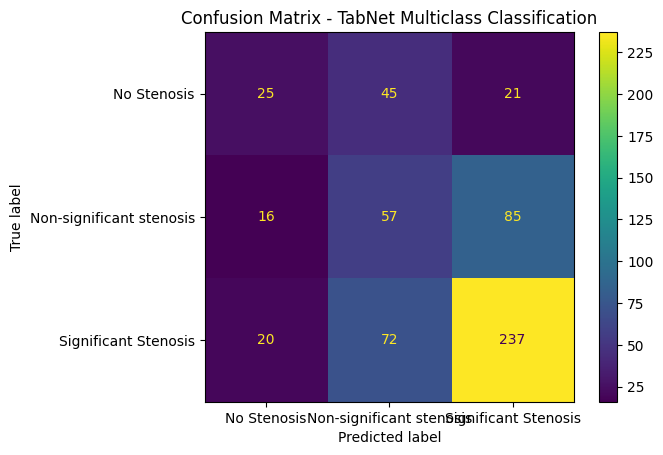


Per-Class Recall:
  No Stenosis (Class 0): 0.2747
  Non-significant stenosis (Class 1): 0.3608
  Significant Stenosis (Class 2): 0.7204


In [41]:
y_pred = tabnet.predict(X_test_selected)
y_proba = tabnet.predict_proba(X_test_selected)

print("=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

print("\n" + "=" * 80)
print("Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]))

print("\n" + "=" * 80)
print("Confusion Matrix:")
print("=" * 80)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]).plot()
plt.title("Confusion Matrix - TabNet Multiclass Classification")
plt.show()

recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]
recall_class0 = recall_score(y_test, y_pred, labels=[0], average=None)[0]
recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]

print(f"\nPer-Class Recall:")
print(f"  No Stenosis (Class 0): {recall_class0:.4f}")
print(f"  Non-significant stenosis (Class 1): {recall_class1:.4f}")
print(f"  Significant Stenosis (Class 2): {recall_class2:.4f}")


## 9. Overfitting Check

This cell compares training and test set performance to detect overfitting:
- Calculates metrics on both training and test sets
- Compares balanced accuracy, recall, and overall accuracy
- Identifies performance gaps that indicate overfitting
- Helps validate model generalization


In [ ]:
y_pred_train = tabnet.predict(X_train_selected)

train_recall_class2 = recall_score(y_train, y_pred_train, labels=[2], average=None)[0]
test_recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]

train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 2)")
print("=" * 80)
print(f"\nRecall (Significant Stenosis - Class 2):")
print(f"  Training: {train_recall_class2:.4f}")
print(f"  Test:     {test_recall_class2:.4f}")
print(f"  Gap:      {train_recall_class2 - test_recall_class2:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

gap_recall = train_recall_class2 - test_recall_class2
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("Model shows good generalization (small gap between train/test)")
    print(f"  Recall gap (Class 2): {gap_recall:.4f} (good)")
    print(f"  Balanced accuracy gap: {gap_bal:.4f} (good)")


## 10. Visualization: ROC and Precision-Recall Curves

This cell visualizes model performance with multiclass ROC and Precision-Recall curves:
- Plots ROC curves for each class (One-vs-Rest approach)
- Plots Precision-Recall curves for each class
- Shows AUC and Average Precision for each class
- Provides visual assessment of model performance across all classes


In [ ]:
clf = tabnet
classes = clf.classes_

class_names = {
    0: "No Stenosis",
    1: "Non-significant stenosis",
    2: "Significant Stenosis"
}

Y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — TabNet Multiclass Classification")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — TabNet Multiclass Classification")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 11. TabNet Feature Importance

This cell visualizes TabNet's interpretable feature attributions:
- TabNet provides feature importance through attention mechanisms
- Shows which features are most important for predictions
- Provides interpretability unique to TabNet architecture
- Plots top 15 most important features


In [ ]:
feature_importances = tabnet.feature_importances_
all_feature_names = preprocessor.get_feature_names_out()
selected_feature_names = all_feature_names[selected_features_mask]

importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features (TabNet Attention-based):")
print(importance_df.head(15).to_string(index=False))

print(f"\nNote: TabNet's attention mechanism automatically learned these feature importances.")
print(f"Features with low importance were naturally ignored due to sparsity regularization.")

plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - TabNet Multiclass Classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 12. Hyperparameter Optimization (Optional)

This cell performs hyperparameter optimization for TabNet:
- Tests different combinations of TabNet hyperparameters
- Uses cross-validation to evaluate parameter combinations
- Finds optimal hyperparameters for the TabNet classifier
- Can be skipped if using default parameters

**Note:** TabNet hyperparameter optimization can be computationally expensive. Consider using a smaller search space or fewer epochs for faster results.


In [ ]:
optimize_hyperparameters = False

if optimize_hyperparameters:
    param_combinations = [
        {'n_d': 32, 'n_a': 32, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-3},
        {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 1e-3},
        {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 5e-4},
        {'n_d': 128, 'n_a': 128, 'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 1e-3},
    ]
    
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results = []
    
    print("Testing different TabNet hyperparameter combinations...")
    print("=" * 60)
    
    for i, params in enumerate(param_combinations):
        print(f"\nCombination {i+1}/{len(param_combinations)}: {params}")
        
        tabnet_params_test = {
            'n_d': params['n_d'],
            'n_a': params['n_a'],
            'n_steps': params['n_steps'],
            'gamma': params['gamma'],
            'lambda_sparse': params['lambda_sparse'],
            'optimizer_fn': torch.optim.Adam,
            'optimizer_params': {'lr': 2e-2},
            'mask_type': 'entmax',
            'n_shared': 2,
            'n_independent': 2,
            'clip_value': 2.0,
            'verbose': 0,
            'seed': 42,
            'device_name': 'cpu'
        }
        
        cv_scores = []
        
        for train_idx, val_idx in cv_strategy.split(X_train_selected, y_train):
            X_train_cv, X_val_cv = X_train_selected[train_idx], X_train_selected[val_idx]
            y_train_cv, y_val_cv = y_train[train_idx], y_train[val_idx]
            
            X_train_cv_balanced, y_train_cv_balanced = smote.fit_resample(X_train_cv, y_train_cv)
            
            tabnet_cv = TabNetClassifier(**tabnet_params_test)
            tabnet_cv.fit(
                X_train=X_train_cv_balanced,
                y_train=y_train_cv_balanced,
                eval_set=[(X_val_cv, y_val_cv)],
                eval_name=['val'],
                eval_metric=['logloss'],
                max_epochs=100,
                patience=10,
                batch_size=1024,
                virtual_batch_size=128,
                num_workers=0,
                drop_last=False,
                verbose=0
            )
            
            y_pred_cv = tabnet_cv.predict(X_val_cv)
            cv_scores.append(balanced_accuracy_score(y_val_cv, y_pred_cv))
        
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        results.append({
            'params': params,
            'cv_mean': mean_score,
            'cv_std': std_score
        })
        
        print(f"CV Balanced Accuracy: {mean_score:.4f} (+/- {std_score*2:.4f})")
    
    results_df = pd.DataFrame(results)
    best_idx = results_df['cv_mean'].idxmax()
    best_params = results_df.loc[best_idx, 'params']
    best_score = results_df.loc[best_idx, 'cv_mean']
    
    print("\n" + "=" * 60)
    print(f"Best parameters: {best_params}")
    print(f"Best CV Balanced Accuracy: {best_score:.4f}")
    print(f"\nRecommendation: Consider using these parameters for improved performance")
else:
    print("Hyperparameter Optimization skipped. Using default parameters.")
